# 01 · Preprocesado del dataset de EGFR

## Objetivo
Este notebook transforma la exportación bruta de ChEMBL en una base reproducible para modelado generativo.

La idea correcta es separar dos artefactos:

- `data/model_preprocesed_dataset.csv`: dataset canónico, filtrado y agregado, útil para análisis, auditoría y validación.
- `data/model_procesed_dataset.csv`: dataset mínimo de entrenamiento para el fine-tuning de MRL, con SMILES canónicos activos.

## Decisión importante
Antes de agrupar, los SMILES se canonicalizan con RDKit. Si agrupas por SMILES sin canonicalizar, puedes tratar como moléculas distintas dos strings que representan la misma estructura química.

## Idea clave
Aquí no se entrena ningún generador. Este notebook solo prepara datos. El fine-tuning de MRL debe consumir `model_procesed_dataset.csv`.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_PATH = Path("../data/egfr_activity_IC50.csv")


## Carga de datos

El archivo de datos brutos empleado en este trabajo se localiza en la ruta `data/egfr_activity_IC50.csv` y se encuentra delimitado por punto y coma (`;`).

Este conjunto de datos fue descargado directamente desde la base de datos **ChEMBL**, aplicando exclusivamente los siguientes filtros previos a la exportación:

- Identificador de la diana: `target_chembl_id = CHEMBL203`
- Tipo de medida biológica: `Standard Type = IC50`

La aplicación de estos criterios produjo un total de **25.758 observaciones**.

El archivo CSV original puede consultarse y descargarse desde el siguiente enlace:

[Descargar datos desde ChEMBL](https://www.ebi.ac.uk/chembl/explore/activities/STATE_ID:_aQnuB2dbSe9ysatmMAANA%3D%3D)


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No existe {DATA_PATH}. Copia aquí la exportación de ChEMBL antes de continuar."
    )

df_raw = pd.read_csv(DATA_PATH, sep=";")
print(f"Dimensión inicial del dataset bruto: {df_raw.shape}")
df_raw.head()


Dimensión inicial del dataset bruto: (25758, 48)


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,pChEMBL Value,Data Validity Comment,Comment,Uo Units,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI,Potential Duplicate,Assay ChEMBL ID,Assay Description,Assay Type,BAO Format ID,BAO Label,Assay Organism,Assay Tissue ChEMBL ID,Assay Tissue Name,Assay Cell Type,Assay Subcellular Fraction,Assay Parameters,Assay Variant Accession,Assay Variant Mutation,Target ChEMBL ID,Target Name,Target Organism,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL6034481,NaN,NaN,574.71,2.0,5.70,BDBM517794,C=CC(=O)Nc1cc(Nc2ncc(C)c(-c3cc(F)c4nc(C)n(C(C)...,IC50,'=',25.0,nM,7.60,NaN,1092556,UO_0000065,13.23,0.25,1.90,7.57,0,CHEMBL5737313,Kinase Inhibition Assay: Reagents and Material...,B,BAO_0000357,single protein format,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL203,Epidermal growth factor receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL5728717,37,BindingDB Patent Bioactivity Data,NaN,2021.0,NaN,NaN,NaN,NaN,25.0
1,CHEMBL5962799,NaN,NaN,563.70,2.0,6.05,BDBM517803,C=CC(=O)Nc1cc(Nc2nccc(-c3cc(F)c4nc(C)n(C(C)C)c...,IC50,'<',1.0,nM,NaN,NaN,1092575,UO_0000065,NaN,NaN,NaN,NaN,0,CHEMBL5737314,Kinase Inhibition Assay: Reagents and Material...,B,BAO_0000357,single protein format,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL203,Epidermal growth factor receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL5728717,37,BindingDB Patent Bioactivity Data,NaN,2021.0,NaN,NaN,NaN,NaN,1.0
2,CHEMBL6061951,NaN,NaN,545.62,2.0,5.24,BDBM517808,C=CC(=O)Nc1cc(Nc2nccc(-c3cc(F)c4nc(C)n(C(C)C)c...,IC50,'=',25.0,nM,7.60,NaN,1092585,UO_0000065,13.93,0.26,2.36,7.14,0,CHEMBL5737314,Kinase Inhibition Assay: Reagents and Material...,B,BAO_0000357,single protein format,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL203,Epidermal growth factor receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL5728717,37,BindingDB Patent Bioactivity Data,NaN,2021.0,NaN,NaN,NaN,NaN,25.0
3,CHEMBL1254199,NaN,NaN,408.30,0.0,4.66,4,CN(c1cccc(Br)c1)c1nc(N)nc2[nH]c(Cc3ccccc3)cc12,IC50,'=',53100.0,nM,4.28,NaN,NaN,UO_0000065,10.47,0.22,-0.39,6.04,0,CHEMBL1252156,Inhibition of EGFR expressed in human A431 cells,B,BAO_0000219,cell-based format,NaN,NaN,NaN,A-431,NaN,NaN,NaN,NaN,CHEMBL203,Epidermal growth factor receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL1250424,1,Scientific Literature,Bioorg Med Chem,2010.0,CHEMBL3307523,NaN,NaN,NaN,53.1
4,CHEMBL1254286,NaN,NaN,422.33,0.0,4.67,6,CN(c1cccc(Br)c1)c1nc(N)nc2c1cc(Cc1ccccc1)n2C,IC50,'=',253600.0,nM,NaN,Outside typical range,NaN,UO_0000065,NaN,NaN,NaN,NaN,0,CHEMBL1252156,Inhibition of EGFR expressed in human A431 cells,B,BAO_0000219,cell-based format,NaN,NaN,NaN,A-431,NaN,NaN,NaN,NaN,CHEMBL203,Epidermal growth factor receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL1250424,1,Scientific Literature,Bioorg Med Chem,2010.0,CHEMBL3307523,NaN,NaN,NaN,253.6


In [3]:
# Eliminamos columnas innecesarias
COLUMNAS_A_ELIMINAR = [
    "Molecule ChEMBL ID",
    "Molecule Name",
    "Molecule Max Phase",
    "Molecular Weight",
    "Compound Key",
    "Value",
    "Uo Units",
    "Ligand Efficiency BEI",
    "Ligand Efficiency SEI",
    "Assay Description",
    "BAO Format ID",
    "Assay Tissue ChEMBL ID",
    "Assay Tissue Name",
    "Assay Cell Type",
    "Assay Subcellular Fraction",
    "Assay Parameters",
    "Target Name",
    "Target Type",
    "Document ChEMBL ID",
    "Source ID",
    "Source Description",
    "Document Journal",
    "Document Year",
    "Cell ChEMBL ID",
    "Properties",
    "Standard Text Value",
    "Comment",
]

columnas_presentes_a_eliminar = [col for col in COLUMNAS_A_ELIMINAR if col in df_raw.columns]

df_raw = df_raw.drop(columns=columnas_presentes_a_eliminar).copy()
print(f"Dimensión tras eliminación de columnas: {df_raw.shape}")

Dimensión tras eliminación de columnas: (25758, 21)


## Inspección inicial de estructura


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 25758 entries, 0 to 25757
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   #RO5 Violations          25447 non-null  float64
 1   AlogP                    25447 non-null  float64
 2   Smiles                   25711 non-null  str    
 3   Standard Type            25758 non-null  str    
 4   Standard Relation        24366 non-null  str    
 5   Standard Value           24363 non-null  float64
 6   Standard Units           24505 non-null  str    
 7   pChEMBL Value            18650 non-null  float64
 8   Data Validity Comment    503 non-null    str    
 9   Ligand Efficiency LE     17175 non-null  float64
 10  Ligand Efficiency LLE    17175 non-null  float64
 11  Potential Duplicate      25758 non-null  int64  
 12  Assay ChEMBL ID          25758 non-null  str    
 13  Assay Type               25758 non-null  str    
 14  BAO Label                25758 no

In [5]:
for col in ["Target ChEMBL ID", "Standard Type", "Standard Units"]:
    if col in df_raw.columns:
        display(df_raw[col].value_counts(dropna=False).head(15))


Target ChEMBL ID
CHEMBL203    25758
Name: count, dtype: int64

Standard Type
IC50    25758
Name: count, dtype: int64

Standard Units
nM             24410
NaN             1253
ug.mL-1           87
/uM                6
10^-5 mol/L        1
10^3 uM            1
Name: count, dtype: int64


- `Target ChEMBL ID` debería estar dominado por CHEMBL203 si la exportación fue correcta. ✅
- `Standard Type` debería contener `IC50`. ✅
- `Standard Units` debería estar normalizado, idealmente en `nM`. ⚠️ (FILTRAR)


## Ejecución del pipeline de preprocesado


In [6]:
from typing import Optional

try:
    from rdkit import Chem
except ImportError:  # pragma: no cover
    Chem = None

In [7]:
def _require_rdkit() -> None:
    """
    Verifica que RDKit esté disponible antes de ejecutar funciones químicas.

    Lanza
    -----
    ImportError
        Si RDKit no está instalado en el entorno actual.
    """
    if Chem is None:
        raise ImportError(
            "RDKit no está disponible. Instálalo para usar las funciones químicas del proyecto."
        )


def mol_from_smiles(smiles: str):
    """
    Convierte un SMILES a una molécula RDKit.

    Returns
    -------
    rdkit.Chem.rdchem.Mol | None
        Molécula válida o `None` si el SMILES no puede parsearse.
    """
    _require_rdkit()
    if smiles is None or pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def canonicalize_smiles(smiles: str) -> Optional[str]:
    """
    Devuelve el SMILES canónico de una estructura válida.

    Returns
    -------
    str | None
        SMILES canónico o `None` si la entrada es inválida.
    """
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


def normalizar_tipos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normaliza tipos de dato y homogeneiza texto y valores nulos.

    Parámetros
    ----------
    df : pd.DataFrame
        Tabla original exportada desde ChEMBL.

    Returns
    -------
    pd.DataFrame
        Copia del dataframe con columnas de texto limpias y columnas numéricas convertidas.
    """
    data = df.copy()

    columnas_texto = [
        "Smiles",
        "Standard Type",
        "Standard Relation",
        "Standard Units",
        "Data Validity Comment",
        "Assay ChEMBL ID",
        "Assay Type",
        "BAO Label",
        "Assay Organism",
        "Assay Variant Accession",
        "Assay Variant Mutation",
        "Target ChEMBL ID",
        "Target Organism",
        "Action Type",
    ]

    for col in columnas_texto:
        if col in data.columns:
            data[col] = data[col].astype("string").str.strip()

    representaciones_nulas = {"", "None", "none", "nan", "NaN", "NAN", "null", "NULL"}
    for col in columnas_texto:
        if col in data.columns:
            data[col] = data[col].replace({x: pd.NA for x in representaciones_nulas})

    if "Standard Relation" in data.columns:
        data["Standard Relation"] = (
            data["Standard Relation"]
            .str.replace('"', "", regex=False)
            .str.replace("'", "", regex=False)
            .str.strip()
        )

    columnas_numericas = [
        "#RO5 Violations",
        "AlogP",
        "Standard Value",
        "pChEMBL Value",
        "Ligand Efficiency LE",
        "Ligand Efficiency LLE",
    ]
    for col in columnas_numericas:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    return data


def filtrar_registros_base(
    df: pd.DataFrame,
    target_chembl_id: str = "CHEMBL203",
    standard_type: str = "IC50",
    standard_units: str = "nM",
) -> pd.DataFrame:
    """
    Aplica filtros mínimos para quedarse con medidas comparables de EGFR.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset normalizado.
    target_chembl_id : str, default="CHEMBL203"
        Identificador ChEMBL de la diana.
    standard_type : str, default="IC50"
        Tipo de medida bioactiva aceptada.
    standard_units : str, default="nM"
        Unidad que se considera comparable.

    Returns
    -------
    pd.DataFrame
        Tabla filtrada, todavía a nivel de ensayo/registro.
    """
    data = df.copy()

    required = ["Smiles", "Standard Value", "Target ChEMBL ID", "Standard Type", "Standard Units"]
    missing = [c for c in required if c not in data.columns]
    if missing:
        raise ValueError(f"Faltan columnas obligatorias para filtrar: {missing}")

    mask = (
        data["Smiles"].notna()
        & data["Standard Value"].notna()
        & (data["Target ChEMBL ID"] == target_chembl_id)
        & (data["Standard Type"] == standard_type)
        & (data["Standard Units"] == standard_units)
    )
    data = data.loc[mask].copy()

    if "Data Validity Comment" in data.columns:
        data = data[data["Data Validity Comment"].isna()].copy()

    if "Standard Relation" in data.columns:
        data = data[data["Standard Relation"] == "="].copy()

    data = data[data["Standard Value"] > 0].copy()
    return data


def canonicalizar_smiles_dataframe(
    df: pd.DataFrame,
    smiles_col: str = "Smiles",
    keep_original: bool = True,
) -> pd.DataFrame:
    """
    Canonicaliza los SMILES antes de agregar registros experimentales.

    Motivo
    ------
    Dos cadenas SMILES distintas pueden representar la misma molécula. Si agrupas
    antes de canonicalizar, puedes dejar duplicados químicos escondidos y calcular
    medianas separadas para la misma estructura.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset filtrado a nivel de registro.
    smiles_col : str, default="Smiles"
        Columna que contiene los SMILES originales.
    keep_original : bool, default=True
        Si es True, conserva el SMILES original en `Smiles_original`.

    Returns
    -------
    pd.DataFrame
        Dataset con `Smiles` reemplazado por SMILES canónicos válidos.
    """
    if smiles_col not in df.columns:
        raise ValueError(f"No existe la columna de SMILES: {smiles_col}")

    data = df.copy()
    if keep_original and "Smiles_original" not in data.columns:
        data["Smiles_original"] = data[smiles_col]

    data["Smiles"] = data[smiles_col].apply(canonicalize_smiles)
    data = data[data["Smiles"].notna()].copy()
    return data


def agregar_por_smiles(
    df: pd.DataFrame,
    active_threshold_pic50: float = 6.0,
    strong_threshold_pic50: float = 7.0,
    training_min_pic50: float = 5.5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Agrega registros repetidos por SMILES canónico y crea el dataset de fine-tuning.

    La agregación usa la mediana de `Standard Value` para amortiguar medidas extremas
    y luego transforma la potencia a pIC50.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset filtrado y con SMILES ya canonicalizados.
    active_threshold_pic50 : float, default=6.0
        Umbral para marcar una molécula como activa.
    strong_threshold_pic50 : float, default=7.0
        Umbral para marcar una molécula como fuertemente activa.
    training_min_pic50 : float, default=5.5
        Umbral mínimo de pIC50 para incluir moléculas en el dataset de fine-tuning.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        - data_preprocessed:
            Dataset agregado completo para análisis y trazabilidad.
        - model_processed_dataset:
            Dataset mínimo para fine-tuning de MRL. Contiene solo una columna:
            `smiles`.
    """
    if df.empty:
        raise ValueError(
            "El dataframe de entrada está vacío después del filtrado/canonicalización."
        )

    aggregations = {
        "n_registros": ("Smiles", "size"),
        "standard_value_nM": ("Standard Value", "median"),
         "ro5_violations": ("#RO5 Violations", "median"),
        "alogp": ("AlogP", "median"),
        "le": ("Ligand Efficiency LE", "median"),
        "lle": ("Ligand Efficiency LLE", "median"),
    }


    if "Smiles_original" in df.columns:
        aggregations["n_smiles_originales"] = (
            "Smiles_original",
            lambda x: x.dropna().nunique(),
        )

    grouped = (
        df.groupby("Smiles", dropna=False, as_index=False)
        .agg(**aggregations)
    )

    grouped["pIC50"] = 9 - np.log10(grouped["standard_value_nM"].astype(float))

    grouped["active"] = (
        grouped["pIC50"] >= active_threshold_pic50
    ).astype(int)

    grouped["strong_active"] = (
        grouped["pIC50"] >= strong_threshold_pic50
    ).astype(int)

    data_preprocessed = (
        grouped
        .sort_values("pIC50", ascending=False)
        .reset_index(drop=True)
        .copy()
    )

    model_processed_dataset = (
        data_preprocessed
        .loc[data_preprocessed["pIC50"] >= training_min_pic50, ["Smiles"]]
        .dropna(subset=["Smiles"])
        .drop_duplicates()
        .rename(columns={"Smiles": "smiles"})
        .reset_index(drop=True)
        .copy()
    )

    return data_preprocessed, model_processed_dataset


def preprocesar_bioactividad_egfr(
    df: pd.DataFrame,
    target_chembl_id: str = "CHEMBL203",
    standard_type: str = "IC50",
    standard_units: str = "nM",
    active_threshold_pic50: float = 6.0,
    strong_threshold_pic50: float = 7.0,
    training_min_pic50: float = 5.5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Ejecuta el pipeline completo de limpieza, canonicalización y agregación para EGFR.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        - `data_preprocessed`: moléculas canónicas agregadas, con actividad y trazabilidad.
        - `model_processed_dataset`: SMILES canónicos activos para fine-tuning de MRL.
    """
    clean = normalizar_tipos(df)
    filtered = filtrar_registros_base(
        clean,
        target_chembl_id=target_chembl_id,
        standard_type=standard_type,
        standard_units=standard_units,
    )
    canonical = canonicalizar_smiles_dataframe(filtered, smiles_col="Smiles", keep_original=True)
    return agregar_por_smiles(
        canonical,
        active_threshold_pic50=active_threshold_pic50,
        strong_threshold_pic50=strong_threshold_pic50,
        training_min_pic50=training_min_pic50,
    )


In [8]:
data_preprocessed, model_processed_dataset = preprocesar_bioactividad_egfr(
    df=df_raw,
    target_chembl_id="CHEMBL203",
    standard_type="IC50",
    standard_units="nM",
    active_threshold_pic50=6.0,
    strong_threshold_pic50=7.0,
    training_min_pic50=5.5,
)

print("Dataset canónico agregado para análisis:", data_preprocessed.shape)
print("Dataset MRL para fine-tuning:", model_processed_dataset.shape)

display(data_preprocessed.head(10))
display(model_processed_dataset.head(10))


Dataset canónico agregado para análisis: (10466, 11)
Dataset MRL para fine-tuning: (8553, 1)


,Smiles,n_registros,standard_value_nM,ro5_violations,alogp,le,lle,n_smiles_originales,pIC50,active,strong_active
0,Cn1cnc2cc3ncnc(Nc4cccc(Br)c4)c3cc21,1,0.0100,0.0,4.02,0.680,6.98,1,11.000000,1,1
1,Cn1cnc2cc3c(Nc4cccc(Br)c4)ncnc3cc21,1,0.0250,0.0,4.02,0.660,6.58,1,10.602060,1,1
2,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1N1CC2(CN(C)C2)...,2,0.0340,0.0,3.82,0.465,6.72,1,10.468521,1,1
3,CCCN1CC2(C1)CN(c1cc3c(Nc4cccc(Cl)c4F)ncnc3cc1O...,2,0.0365,0.0,4.60,0.435,5.88,1,10.437707,1,1
4,C=CC(=O)Nc1ccc2ncnc(Nc3cc(F)c(Cl)c(Cl)c3)c2c1,1,0.0370,0.0,4.94,0.570,5.49,1,10.431798,1,1
5,CCN1CC2(C1)CN(c1cc3c(Nc4cccc(Cl)c4F)ncnc3cc1OC...,2,0.0455,0.0,4.21,0.440,6.20,1,10.341989,1,1
6,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1N1C[C@H](CN(C)...,1,0.0500,0.0,4.06,0.450,6.24,1,10.301030,1,1
7,CN1CCC2(CC1)CN(c1ccc3ncnc(Nc4cccc(Cl)c4F)c3c1)...,2,0.0510,0.0,4.59,0.455,5.83,1,10.292430,1,1
8,COc1cc(N2CCC3(CC2)CN(C)C3)c(C)cc1Nc1ncc(Br)c(N...,1,0.0520,2.0,6.98,0.330,3.30,1,10.283997,1,1
9,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1N1CC2(CCN(C)CC...,2,0.0600,0.0,4.60,0.425,5.75,1,10.221849,1,1


,smiles
0,Cn1cnc2cc3ncnc(Nc4cccc(Br)c4)c3cc21
1,Cn1cnc2cc3c(Nc4cccc(Br)c4)ncnc3cc21
2,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1N1CC2(CN(C)C2)...
3,CCCN1CC2(C1)CN(c1cc3c(Nc4cccc(Cl)c4F)ncnc3cc1O...
4,C=CC(=O)Nc1ccc2ncnc(Nc3cc(F)c(Cl)c(Cl)c3)c2c1
5,CCN1CC2(C1)CN(c1cc3c(Nc4cccc(Cl)c4F)ncnc3cc1OC...
6,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1N1C[C@H](CN(C)...
7,CN1CCC2(CC1)CN(c1ccc3ncnc(Nc4cccc(Cl)c4F)c3c1)...
8,COc1cc(N2CCC3(CC2)CN(C)C3)c(C)cc1Nc1ncc(Br)c(N...
9,COc1cc2ncnc(Nc3cccc(Cl)c3F)c2cc1N1CC2(CCN(C)CC...


Este preprocesado produce dos datasets con objetivos distintos. Mezclarlos sería un error de diseño.

## `model_preprocesed_dataset.csv`

Dataset completo para análisis, trazabilidad y validación. Contiene moléculas agregadas por SMILES canónico junto con métricas de actividad biológica y propiedades procedentes de ChEMBL.

`Smiles` -> Representación canónica de la estructura química.

- Se obtiene con RDKit antes de agrupar.
- Reduce duplicados artificiales causados por diferentes escrituras del mismo compuesto.
- Es la columna base para generación, scoring y análisis posterior.

`standard_value_nM` -> Valor experimental agregado de actividad IC50 en **nanomolar (nM)**.

- Se calcula como la mediana de los registros disponibles para la misma molécula canónica.
- Valores más bajos ⇒ mayor potencia.

`pIC50` -> Transformación logarítmica de la actividad.

$$
pIC50 = 9 - \log_{10}(\text{IC50 en nM})
$$

- Valores más altos ⇒ mayor potencia.
- Permite comparar moléculas en una escala más estable.

`n_registros` -> Número de mediciones experimentales asociadas al SMILES canónico.

- Más registros no garantizan verdad absoluta, pero sí más trazabilidad.

`n_smiles_originales` -> Número de representaciones SMILES originales que colapsaron en el mismo SMILES canónico.

- Sirve para auditar cuánto duplicado estructural escondido había antes de canonicalizar.

`active` -> Etiqueta binaria de actividad definida como `pIC50 >= 6`.

`strong_active` -> Etiqueta de alta actividad definida como `pIC50 >= 7`.

`ro5_violations` -> Número de violaciones de la Regla de Lipinski.

`alogp` -> Estimación de lipofilia.

`le` -> Ligand Efficiency.

$$
LE = \frac{1.37 \cdot pIC50}{N_{\text{heavy atoms}}}
$$

`lle` -> Lipophilic Ligand Efficiency.

$$
LLE = pIC50 - \log P
$$

## `model_procesed_dataset.csv`

Dataset mínimo para fine-tuning de MRL.

`Smiles` -> SMILES canónicos de moléculas activas (`pIC50 >= 6`).

- No incluye descriptores químicos.
- No incluye QED.
- No incluye scaffold.
- No incluye fingerprints Morgan.

La razón es simple: el fine-tuning del generador de SMILES aprende una distribución de strings/moléculas. Los descriptores pertenecen al scoring, recompensa, filtrado y validación posterior, no al CSV mínimo de entrenamiento.


## Comparación entre dataset bruto y dataset limpio


In [9]:
raw_unique = df_raw["Smiles"].nunique(dropna=True)
canonical_unique = data_preprocessed["Smiles"].nunique(dropna=True)
mrl_unique = model_processed_dataset["smiles"].nunique(dropna=True)

print(f"SMILES únicos en bruto: {raw_unique}")
print(f"Moléculas únicas tras canonicalización/agregación: {canonical_unique}")
print(f"SMILES activos para fine-tuning MRL: {mrl_unique}")

if "n_smiles_originales" in data_preprocessed.columns:
    colapsados = (data_preprocessed["n_smiles_originales"] > 1).sum()
    print(f"Moléculas donde varios SMILES originales colapsaron al mismo canónico: {colapsados}")


SMILES únicos en bruto: 14438
Moléculas únicas tras canonicalización/agregación: 10466
SMILES activos para fine-tuning MRL: 8553
Moléculas donde varios SMILES originales colapsaron al mismo canónico: 0


## Distribución de pIC50


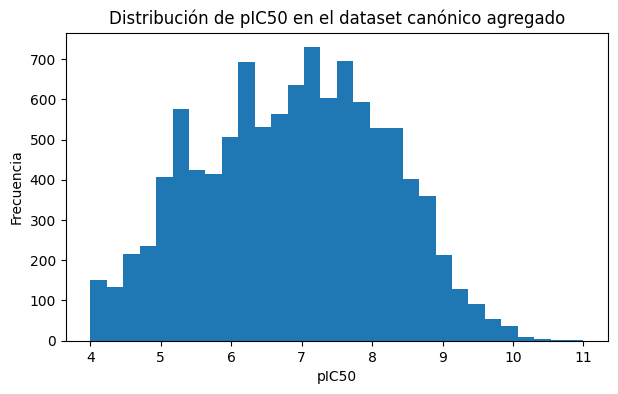

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(data_preprocessed["pIC50"].dropna(), bins=30)
plt.title("Distribución de pIC50 en el dataset canónico agregado")
plt.xlabel("pIC50")
plt.ylabel("Frecuencia")
plt.show()


## Balance de etiquetas de actividad


In [11]:
display(data_preprocessed[["active", "strong_active"]].mean().mul(100).round(2).to_frame("%"))


,%
active,73.45
strong_active,48.85


## Exportación


In [12]:
output_a = Path("../data/model_preprocesed_dataset.csv")
output_b = Path("../data/model_procesed_dataset.csv")

output_a.parent.mkdir(parents=True, exist_ok=True)
data_preprocessed.to_csv(output_a, index=False)
model_processed_dataset.to_csv(output_b, index=False)

print(f"Guardado dataset completo de análisis: {output_a.resolve()}")
print(f"Guardado dataset MRL fine-tuning: {output_b.resolve()}")


Guardado dataset completo de análisis: /home/kluna/TFM/tfm_project/data/model_preprocesed_dataset.csv
Guardado dataset MRL fine-tuning: /home/kluna/TFM/tfm_project/data/model_procesed_dataset.csv
